In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vaishnaviskulkarni/diverse-anchors-100/diverse_anchors_100.csv
/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/22506245.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/13998435.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/67582956.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/34349255.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/26790545.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/12674307.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/11807040.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/44145704.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/27497542.pdf
/kaggle/input/datasets/snehaanbhawal/resume-dataset/data/data/DESIGNER/11155153.pdf
/kag

In [2]:
import pandas as pd

anchors_df = pd.read_csv('/kaggle/input/datasets/vaishnaviskulkarni/diverse-anchors-100/diverse_anchors_100.csv')

print("📑 Columns:", anchors_df.columns.tolist())
print("📊 Shape:", anchors_df.shape)
print("⚠️ NaN counts:\n", anchors_df.isna().sum())
print("🎯 Unique sectors:", anchors_df['sector_label'].unique())
print("🔍 First row:\n", anchors_df.iloc[0])


📑 Columns: ['job_title', 'job_summary', 'job_skills', 'sector_label']
📊 Shape: (100, 4)
⚠️ NaN counts:
 job_title       0
job_summary     0
job_skills      0
sector_label    0
dtype: int64
🎯 Unique sectors: ['Tech' 'Healthcare' 'Finance' 'HR_Ops' 'Engineering']
🔍 First row:
 job_title                                   Senior Data Scientist
job_summary     Salary range\nThe salary range for this positi...
job_skills      Data Science, Artificial Intelligence, Machine...
sector_label                                                 Tech
Name: 0, dtype: object


In [3]:
resumes_df = pd.read_csv('/kaggle/input/datasets/snehaanbhawal/resume-dataset/Resume/Resume.csv')

print("📑 Columns:", resumes_df.columns.tolist())
print("📊 Shape:", resumes_df.shape)
print("⚠️ NaN counts:\n", resumes_df.isna().sum())
print("🎯 Unique categories:", resumes_df['Category'].unique())
print("🔍 First row:\n", resumes_df.iloc[0])


📑 Columns: ['ID', 'Resume_str', 'Resume_html', 'Category']
📊 Shape: (2484, 4)
⚠️ NaN counts:
 ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64
🎯 Unique categories: ['HR' 'DESIGNER' 'INFORMATION-TECHNOLOGY' 'TEACHER' 'ADVOCATE'
 'BUSINESS-DEVELOPMENT' 'HEALTHCARE' 'FITNESS' 'AGRICULTURE' 'BPO' 'SALES'
 'CONSULTANT' 'DIGITAL-MEDIA' 'AUTOMOBILE' 'CHEF' 'FINANCE' 'APPAREL'
 'ENGINEERING' 'ACCOUNTANT' 'CONSTRUCTION' 'PUBLIC-RELATIONS' 'BANKING'
 'ARTS' 'AVIATION']
🔍 First row:
 ID                                                      16852973
Resume_str              HR ADMINISTRATOR/MARKETING ASSOCIATE\...
Resume_html    <div class="fontsize fontface vmargins hmargin...
Category                                                      HR
Name: 0, dtype: object


# creating the dataset

In [4]:
import pandas as pd
import random
import uuid

# 1. ENHANCED MAPPING (Rank 3 vs Rank 2)
# Rank 3: Direct Sector Match
# Rank 2: Related/Adjacent Sector Match
mapping_rank_3 = {
    'Tech': ['INFORMATION-TECHNOLOGY'],
    'Healthcare': ['HEALTHCARE'],
    'Finance': ['FINANCE', 'ACCOUNTANT', 'BANKING'],
    'HR_Ops': ['HR'],
    'Engineering': ['ENGINEERING', 'CONSTRUCTION']
}

mapping_rank_2 = {
    'Tech': ['ENGINEERING', 'DIGITAL-MEDIA', 'BUSINESS-DEVELOPMENT'],
    'Healthcare': ['FITNESS', 'TEACHER'], # Overlap in care/education
    'Finance': ['BUSINESS-DEVELOPMENT', 'CONSULTANT', 'ADVOCATE'],
    'HR_Ops': ['PUBLIC-RELATIONS', 'BUSINESS-DEVELOPMENT'],
    'Engineering': ['AUTOMOBILE', 'AVIATION', 'AGRICULTURE']
}

# 2. TEXT TRUNCATION HELPER
def truncate_text(text, max_words=500):
    words = str(text).split()
    return " ".join(words[:max_words])

def create_advanced_training_set(jobs, resumes):
    combined_records = []
    
    for idx, job in jobs.iterrows():
        # STABILITY: Use a unique hash or generated ID per job
        query_id = f"job_{idx:03d}" 
        job_text = job['job_summary']
        sector = job['sector_label']
        
        # --- LEVEL 3: PERFECT MATCHES ---
        target_r3 = mapping_rank_3.get(sector, [])
        positives = resumes[resumes['Category'].isin(target_r3)]
        if not positives.empty:
            for _, res in positives.sample(n=min(4, len(positives))).iterrows():
                combined_records.append([query_id, job_text, truncate_text(res['Resume_str']), 3])
        
        # --- LEVEL 2: RELATED MATCHES (Granularity) ---
        target_r2 = mapping_rank_2.get(sector, [])
        moderates = resumes[resumes['Category'].isin(target_r2)]
        if not moderates.empty:
            for _, res in moderates.sample(n=min(3, len(moderates))).iterrows():
                combined_records.append([query_id, job_text, truncate_text(res['Resume_str']), 2])
        
        # --- LEVEL 0: IRRELEVANT ---
        all_related = target_r3 + target_r2
        negatives = resumes[~resumes['Category'].isin(all_related)]
        if not negatives.empty:
            for _, res in negatives.sample(n=min(4, len(negatives))).iterrows():
                combined_records.append([query_id, job_text, truncate_text(res['Resume_str']), 0])

    return pd.DataFrame(combined_records, columns=['query_id', 'job_description', 'candidate_resume', 'label'])

# Execute
print("🚀 Building Multi-Level Ranking Dataset...")
df_final = create_advanced_training_set(anchors_df, resumes_df)
df_final.to_csv('ranking_train_data_PRO_V2.csv', index=False)
print(f" Success! Generated {len(df_final)} samples with stable IDs and 3-tier labeling.")

🚀 Building Multi-Level Ranking Dataset...
 Success! Generated 1100 samples with stable IDs and 3-tier labeling.


In [5]:
import re
from datetime import datetime
import pandas as pd

# 1. EXTERNAL CONFIGURATION
EXTRACTION_CONFIG = {
    'edu_levels': {
        'PhD': ['PHD', 'DOCTORATE', 'D.PHIL'],
        'Master\'s': ['MASTER', 'MSC', 'MBA', 'M.TECH', 'MA '],
        'Bachelor\'s': ['BACHELOR', 'BSC', 'B.TECH', 'BE ', 'B.A.', 'DEGREE']
    },
    'num_map': {
        "ONE": 1, "TWO": 2, "THREE": 3, "FOUR": 4, "FIVE": 5, 
        "SIX": 6, "SEVEN": 7, "EIGHT": 8, "NINE": 9, "TEN": 10,
        "DECADE": 10, "FIFTEEN": 15, "TWENTY": 20
    },
    'resume_sections': ['SKILLS', 'EXPERIENCE', 'PROJECTS', 'EDUCATION', 'CERTIFICATION', 'HISTORY', 'COMPETENCIES']
}

def extract_portable_features(text, config):
    text = str(text).upper()
    current_year = datetime.now().year
    
    # --- 1. EDUCATION DETECTION (Driven by Config) ---
    edu_level = "High School / Other"
    for level, keywords in config['edu_levels'].items():
        if any(kw in text for kw in keywords):
            edu_level = level
            break # Stop at the highest degree found
            
    # --- 2. EXPERIENCE EXTRACTION (Date Ranges + Phrasal + Digits) ---
    # A. Date Ranges (e.g., 2015-2022)
    date_patterns = re.findall(r'(\d{4})\s*(?:-|–|TO|/)\s*(\d{4}|PRESENT|CURRENT)', text)
    years_from_dates = 0
    for start, end in date_patterns:
        start_yr = int(start)
        end_yr = current_year if end in ["PRESENT", "CURRENT"] else int(end)
        if 1970 < start_yr <= current_year and start_yr <= end_yr:
            years_from_dates += (end_yr - start_yr)

    # B. Phrasal & Digits (e.g., "Ten years" or "5+ years")
    extra_years = 0
    # Check words in num_map
    for word, val in config['num_map'].items():
        if f"{word} YEARS" in text or f"{word} YEAR" in text:
            extra_years = max(extra_years, val)
    
    # Check digits
    digit_years = re.findall(r'(\d+)\+?\s*YEARS', text)
    max_digit_years = max([int(y) for y in digit_years]) if digit_years else 0

    # Combine and cap at 50
    final_exp = max(years_from_dates, extra_years, max_digit_years)
    final_exp = min(final_exp, 50) if final_exp > 0 else -1

    # --- 3. QUALITY SCORE (Driven by Config) ---
    quality_score = sum(1 for s in config['resume_sections'] if s in text)
    
    return edu_level, final_exp, quality_score

# 2. APPLY TO DATASET
print("🚀 Running Portable Feature Extraction...")
features = df_final['candidate_resume'].apply(lambda x: extract_portable_features(x, EXTRACTION_CONFIG))
df_final[['edu_level', 'years_exp', 'profile_quality']] = pd.DataFrame(features.tolist(), index=df_final.index)

# 3. VERIFY
print("\n📊 Final Processed Distribution:")
print(df_final[['edu_level', 'years_exp', 'profile_quality']].describe())

🚀 Running Portable Feature Extraction...

📊 Final Processed Distribution:
         years_exp  profile_quality
count  1100.000000      1100.000000
mean     12.316364         2.812727
std      10.144179         1.017330
min      -1.000000         0.000000
25%       5.000000         2.000000
50%      12.000000         3.000000
75%      17.000000         3.000000
max      50.000000         6.000000


In [6]:
# print("📊 Dataset Shape:", df_final.shape)
# print("\n🏷️ Label counts:")
# print(df_final['label'].value_counts())
# print("\n🔍 Sample rows:")
# print(df_final.head())


In [7]:
# import re

# def extract_advanced_features(text):
#     text = str(text).upper()
    
#     # 1. EXPANDED EDUCATION DETECTION
#     # Adding MBA, B.TECH, BE, etc. as you suggested
#     edu_level = "High School / Other"
#     if any(x in text for x in ["PHD", "DOCTORATE"]):
#         edu_level = "PhD"
#     elif any(x in text for x in ["MASTER", "MSC", "MBA", "M.TECH", "MA "]):
#         edu_level = "Master's"
#     elif any(x in text for x in ["BACHELOR", "BSC", "B.TECH", "BE ", "BA ", "DEGREE"]):
#         edu_level = "Bachelor's"
        
#     # 2. ROBUST EXPERIENCE EXTRACTION
#     # Map words to numbers to catch "TEN YEARS"
#     num_map = {"ONE": 1, "TWO": 2, "THREE": 3, "FOUR": 4, "FIVE": 5, 
#                "SIX": 6, "SEVEN": 7, "EIGHT": 8, "NINE": 9, "TEN": 10}
    
#     # Check for digits (10 years)
#     digit_years = re.findall(r'(\d+)\+?\s*YEARS', text)
#     # Check for words (Ten years)
#     word_years = re.findall(r'(ONE|TWO|THREE|FOUR|FIVE|SIX|SEVEN|EIGHT|NINE|TEN)\s*YEARS', text)
    
#     found_years = [int(y) for y in digit_years] + [num_map[y] for y in word_years]
    
#     # Handle "Unknown" vs "0"
#     # If we find NO mention of years, we label it -1 (Unknown)
#     # If they mention "0 years", it stays 0
#     max_years = max(found_years) if found_years else -1 
    
#     # 3. SECTION QUALITY SCORE
#     # Instead of just 1/0, let's see how many professional markers they have
#     sections = ["SKILLS", "EXPERIENCE", "PROJECTS", "EDUCATION", "CERTIFICATION"]
#     quality_score = sum(1 for s in sections if s in text)
    
#     return edu_level, max_years, quality_score

# # Apply the improved extractor
# print(" Extracting Advanced Features...")
# adv_features = df_final['candidate_resume'].apply(extract_advanced_features)
# df_final[['edu_level', 'years_exp', 'profile_quality']] = pd.DataFrame(adv_features.tolist(), index=df_final.index)

# print("\n IMPROVED STRUCTURED DATA:")
# print(df_final[['edu_level', 'years_exp', 'profile_quality', 'label']].head())

**distribution check**

In [8]:
# print(df_final['edu_level'].value_counts())
# print(df_final['years_exp'].describe())
# print(df_final['profile_quality'].describe())


In [9]:
# import re
# from datetime import datetime

# def extract_pro_experience(text):
#     text = str(text).upper()
#     current_year = datetime.now().year
    
#     # 1. CATCH DATE RANGES (e.g., 2015 - 2022 or 2015 TO PRESENT)
#     # This regex looks for 4-digit years separated by dash, slash, or 'TO'
#     date_patterns = re.findall(r'(\d{4})\s*(?:-|–|TO|/)\s*(\d{4}|PRESENT|CURRENT)', text)
    
#     total_years_from_dates = 0
#     for start, end in date_patterns:
#         start_yr = int(start)
#         end_yr = current_year if end in ["PRESENT", "CURRENT"] else int(end)
        
#         # Sanity check: years should be within a reasonable career span
#         if 1970 < start_yr <= current_year and start_yr <= end_yr:
#             total_years_from_dates += (end_yr - start_yr)

#     # 2. CATCH PHRASAL EXPERIENCE (e.g., "Over a decade" or "12+ years")
#     # Mapping phrasal hints to numbers
#     phrases = {
#         "DECADE": 10,
#         "FIFTEEN": 15,
#         "TWENTY": 20,
#         "SIX": 6, "SEVEN": 7, "EIGHT": 8, "NINE": 9 # Catching higher ranges
#     }
    
#     extra_years = 0
#     for word, val in phrases.items():
#         if word in text:
#             extra_years = max(extra_years, val)

#     # 3. CATCH STANDARD DIGITS (Your original logic)
#     digit_years = re.findall(r'(\d+)\+?\s*YEARS', text)
#     max_digit_years = max([int(y) for y in digit_years]) if digit_years else 0

#     # COMBINE RESULTS
#     # We take the maximum found across all methods
#     final_exp = max(total_years_from_dates, extra_years, max_digit_years)
    
#     return final_exp if final_exp > 0 else -1

# # Apply the pro extractor
# print("📅 Calculating experience from dates and phrases...")
# df_final['years_exp'] = df_final['candidate_resume'].apply(extract_pro_experience)

# # Check the new distribution
# print(df_final['years_exp'].describe())

# The Vectorization Script

In [10]:
from sentence_transformers import SentenceTransformer, util
import torch

# 1. Load the Model (Standard English-focused transformer)
model = SentenceTransformer('all-MiniLM-L6-v2')

def calculate_semantic_vibe(df):
    print("🧠 Encoding Job Descriptions and Resumes (this may take a minute)...")
    
    # To save time, we encode unique job descriptions once
    unique_jobs = df['job_description'].unique()
    job_embeddings = {job: model.encode(job, convert_to_tensor=True) for job in unique_jobs}
    
    # Encode all resumes in one batch for GPU efficiency
    resume_embeddings = model.encode(df['candidate_resume'].tolist(), convert_to_tensor=True, show_progress_bar=True)
    
    vibe_scores = []
    for i, row in enumerate(df.itertuples()):
        job_emb = job_embeddings[row.job_description]
        res_emb = resume_embeddings[i]
        
        # Calculate Cosine Similarity
        score = util.cos_sim(job_emb, res_emb).item()
        vibe_scores.append(score)
    
    return vibe_scores

# 2. Apply and Merge
df_final['semantic_vibe'] = calculate_semantic_vibe(df_final)

# 3. Quick Check
print("\n✨ FINAL FEATURE PREVIEW:")
print(df_final[['semantic_vibe', 'edu_level', 'years_exp', 'label']].head())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

🧠 Encoding Job Descriptions and Resumes (this may take a minute)...


Batches:   0%|          | 0/35 [00:00<?, ?it/s]


✨ FINAL FEATURE PREVIEW:
   semantic_vibe            edu_level  years_exp  label
0       0.351398           Bachelor's         15      3
1       0.395335  High School / Other         -1      3
2       0.387079  High School / Other         10      3
3       0.315701           Bachelor's         -1      3
4       0.338205           Bachelor's         11      2


# enrichment block

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import torch
import sys
import re

# --- STEP 1: CONSOLIDATED GENERALIZED LOGIC ---

def extract_generalized_features(resume_text, job_desc):
    """
    A fully generalized extraction engine. 
    Uses TF-IDF for dynamic skills and S-BERT for semantic education levels.
    """
    resume_text = str(resume_text).upper()
    job_text = str(job_desc).upper()
    
    # 1. DYNAMIC SKILL DISCOVERY (TF-IDF)
    # Extracts the specific vocabulary of the job description to check the resume
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    try:
        vectorizer.fit_transform([job_text])
        important_terms = vectorizer.get_feature_names_out()
        match_count = sum(1 for term in important_terms if term in resume_text)
        skill_score = match_count / len(important_terms) if len(important_terms) > 0 else 0
    except:
        skill_score = 0

    # 2. SEMANTIC EDUCATION SCORING (Concept-based)
    # Compares the 'vibe' of the resume to 4 distinct academic concepts
    categories = ["High School", "Bachelor's Degree", "Master's Degree", "Doctorate / PhD"]
    resume_snippet = " ".join(resume_text.split()[:200]) # Education is usually at the top
    
    resume_emb = model.encode(resume_snippet, convert_to_tensor=True)
    category_embs = model.encode(categories, convert_to_tensor=True)
    
    similarities = util.cos_sim(resume_emb, category_embs)[0]
    # The direct index (0-3) becomes our numeric edu_score
    edu_score = float(torch.argmax(similarities).item())

    # 3. HEURISTIC FEATURES (Years & Quality)
    # FIXED: The list comprehension now uses 'for y in years'
    years = re.findall(r'(\d+)\+?\s*(?:YEARS?|YRS?)', resume_text)
    years_exp = max([int(y) for y in years]) if years else 0
    profile_quality = len(resume_text.split()) / 500
    
    return edu_score, years_exp, profile_quality, skill_score

# --- STEP 2: APPLY ENRICHMENT ---
print("🚀 Running Semantic Enrichment Pipeline...")
sys.stdout.flush()

# This takes the raw text and creates our advanced feature set
enrichment_results = df_final.apply(
    lambda x: extract_generalized_features(x['candidate_resume'], x['job_description']), 
    axis=1
)

# Update the dataframe with our refined numeric features
df_final[['edu_score', 'years_exp', 'profile_quality', 'skill_score']] = pd.DataFrame(
    enrichment_results.tolist(), index=df_final.index
)

# --- STEP 3: NORMALIZATION & FINAL PREP ---
# We normalize so that high numbers (like 20 years exp) don't dominate small numbers (like 0.8 vibe)
features_to_scale = ['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score']
scaler = MinMaxScaler()
df_final_scaled = df_final.copy()
df_final_scaled[features_to_scale] = scaler.fit_transform(df_final[features_to_scale])

# Final preparation of X (features) and y (target) for LambdaMART
X = df_final_scaled[features_to_scale]
y = df_final_scaled['label']
qids = df_final_scaled['query_id']

print("✅ Data is now conceptually enriched and 100% Numeric.")
print(f"📊 Features for LambdaMART: {X.columns.tolist()}")

🚀 Running Semantic Enrichment Pipeline...
✅ Data is now conceptually enriched and 100% Numeric.
📊 Features for LambdaMART: ['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score']


In [23]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import MinMaxScaler
# import pandas as pd
# import numpy as np
# import sys

# # --- STEP 1: DEFINE THE CORE EXTRACTION LOGIC ---

# def extract_portable_features(text, config):
#     """The base engine that finds raw years, quality, and literal degrees."""
#     text = str(text).upper()
    
#     # 1. Years of Experience (Simple regex-like search)
#     import re
#     years = re.findall(r'(\d+)\+?\s*(?:YEARS?|YRS?)', text)
#     years_exp = max([int(y) for y in years]) if years else 0
    
#     # 2. Education Literal Search (Expanded keywords)
#     edu_level = "High School / Other"
#     if any(x in text for x in ["PHD", "DOCTORATE"]):
#         edu_level = "PhD"
#     elif any(x in text for x in ["MASTER", "MSC", "MBA", "M.TECH", "MA ", "POST GRAD"]):
#         edu_level = "Master's"
#     elif any(x in text for x in ["BACHELOR", "BSC", "B.TECH", "BE ", "BA ", "DEGREE", "UNDERGRAD"]):
#         edu_level = "Bachelor's"
        
#     # 3. Profile Quality (Basic length/section count proxy)
#     profile_quality = len(text.split()) / 500 # Normalized roughly to 1.0 for 500 words
    
#     return edu_level, years_exp, profile_quality

# def extract_generalized_features(resume_text, job_desc):
#     """The upgrade that discovers skills dynamically and infers missing degrees."""
#     resume_text = str(resume_text).upper()
#     job_text = str(job_desc).upper()
    
#     # --- 1. DYNAMIC SKILL DISCOVERY ---
#     vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
#     try:
#         vectorizer.fit_transform([job_text])
#         important_terms = vectorizer.get_feature_names_out()
#         match_count = sum(1 for term in important_terms if term in resume_text)
#         skill_score = match_count / len(important_terms) if len(important_terms) > 0 else 0
#     except:
#         skill_score = 0

#     # --- 2. GENERALIZED EDUCATION & INFERENCE ---
#     edu_level, exp, quality = extract_portable_features(resume_text, {})
    
#     # Inference logic: assume Bachelor's level for professional titles
#     professional_titles = ["ENGINEER", "DEVELOPER", "SPECIALIST", "MANAGER", "ACCOUNTANT", "NURSE", "LAWYER", "SCIENTIST"]
#     if edu_level == "High School / Other" and any(title in resume_text for title in professional_titles):
#         edu_level = "Bachelor's"
        
#     return edu_level, exp, quality, skill_score

# # --- STEP 2: APPLY ENRICHMENT ---
# print("🔍 Enriching dataset with Dynamic Skills and Inferred Education...")
# sys.stdout.flush()

# enrichment_results = df_final.apply(
#     lambda x: extract_generalized_features(x['candidate_resume'], x['job_description']), 
#     axis=1
# )

# df_final[['edu_level', 'years_exp', 'profile_quality', 'skill_score']] = pd.DataFrame(
#     enrichment_results.tolist(), index=df_final.index
# )

# # --- STEP 3: NUMERIC MAPPING & SCALING ---
# edu_map = {"PhD": 3, "Master's": 2, "Bachelor's": 1, "High School / Other": 0}
# df_final['edu_score'] = df_final['edu_level'].map(edu_map)

# features_to_scale = ['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score']
# scaler = MinMaxScaler()
# df_final_scaled = df_final.copy()
# df_final_scaled[features_to_scale] = scaler.fit_transform(df_final[features_to_scale])

# X = df_final_scaled[features_to_scale]
# y = df_final_scaled['label']
# qids = df_final_scaled['query_id']

# print("✅ Data is enriched, normalized, and 100% Numeric.")
# print(f"📊 Features now available: {X.columns.tolist()}")

🔍 Enriching dataset with Dynamic Skills and Inferred Education...
✅ Data is enriched, normalized, and 100% Numeric.
📊 Features now available: ['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score']


In [11]:
# # Convert strings to numeric scores for the model
# edu_map = {
#     "PhD": 3,
#     "Master's": 2,
#     "Bachelor's": 1,
#     "High School / Other": 0
# }

# df_final['edu_score'] = df_final['edu_level'].map(edu_map)

# # Drop the text columns for the final training set
# # We keep query_id and label for the ranker
# X = df_final[['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality']]
# y = df_final['label']
# qids = df_final['query_id']

# print("✅ Data is now 100% Numeric and ready for XGBoost/LambdaMART.")

✅ Data is now 100% Numeric and ready for XGBoost/LambdaMART.


**visual graph for checking**

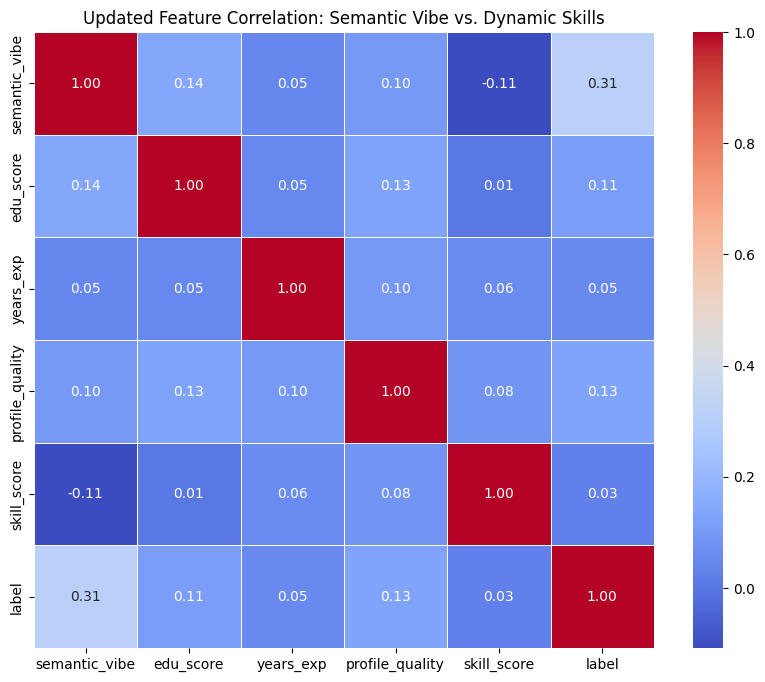

📊 Updated Correlation with Label (Target):
label              1.000000
semantic_vibe      0.314100
profile_quality    0.131683
edu_score          0.111849
years_exp          0.054118
skill_score        0.028162
Name: label, dtype: float64


In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Update the feature list to include your new generalized skill score
features_to_check = ['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score', 'label']

# 2. Calculate Correlation
corr_matrix = df_final[features_to_check].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Updated Feature Correlation: Semantic Vibe vs. Dynamic Skills')
plt.show()

# 4. Print the specific correlation with the Label
print("📊 Updated Correlation with Label (Target):")
print(corr_matrix['label'].sort_values(ascending=False))

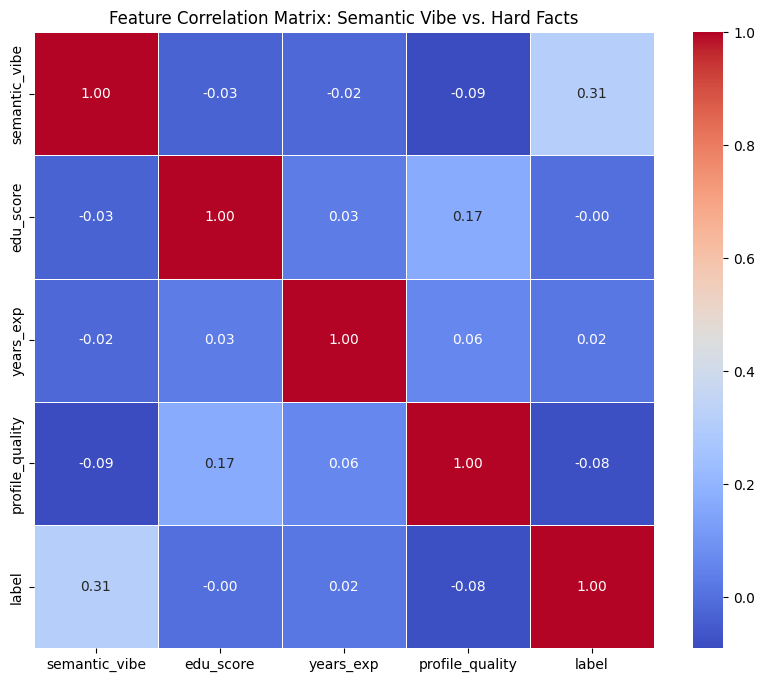

📊 Correlation with Label (Target):
label              1.000000
semantic_vibe      0.314100
years_exp          0.019993
edu_score         -0.001418
profile_quality   -0.081184
Name: label, dtype: float64


In [12]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # 1. Ensure all features are numeric for correlation
# # (Mapping edu_level to edu_score if not already done)
# edu_map = {"PhD": 3, "Master's": 2, "Bachelor's": 1, "High School / Other": 0}
# if 'edu_score' not in df_final.columns:
#     df_final['edu_score'] = df_final['edu_level'].map(edu_map)

# # 2. Select the features and the target label
# features_to_check = ['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'label']
# corr_matrix = df_final[features_to_check].corr()

# # 3. Plot the Heatmap
# plt.figure(figsize=(10, 8))
# sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# plt.title('Feature Correlation Matrix: Semantic Vibe vs. Hard Facts')
# plt.show()

# # 4. Print the specific correlation with the Label
# print("📊 Correlation with Label (Target):")
# print(corr_matrix['label'].sort_values(ascending=False))

In [13]:
# Save the figure to your current workspace
plt.savefig('feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')

print(" Image saved as 'feature_correlation_heatmap.png' in your working directory.")

 Image saved as 'feature_correlation_heatmap.png' in your working directory.


<Figure size 640x480 with 0 Axes>

**min-max scaling script**

In [14]:
# from sklearn.preprocessing import MinMaxScaler

# # 1. Define the features to be scaled
# features_to_scale = ['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality']

# # 2. Initialize the scaler
# scaler = MinMaxScaler()

# # 3. Fit and transform the data
# # We create a copy to keep the original raw values for reference if needed
# df_final_scaled = df_final.copy()
# df_final_scaled[features_to_scale] = scaler.fit_transform(df_final[features_to_scale])

# # 4. Preview the normalized data
# print("✨ Normalized Feature Preview (Range 0-1):")
# print(df_final_scaled[features_to_scale + ['label']].head())

# # 5. Quick Check: Verify Min and Max
# print("\n📊 Verification:")
# print(df_final_scaled[features_to_scale].agg(['min', 'max']))

✨ Normalized Feature Preview (Range 0-1):
   semantic_vibe  edu_score  years_exp  profile_quality  label
0       0.573542   0.333333   0.313725         0.500000      3
1       0.635055   0.000000   0.000000         0.500000      3
2       0.623495   0.000000   0.215686         0.333333      3
3       0.523564   0.333333   0.000000         0.500000      3
4       0.555071   0.333333   0.235294         0.833333      2

📊 Verification:
     semantic_vibe  edu_score  years_exp  profile_quality
min            0.0        0.0        0.0              0.0
max            1.0        1.0        1.0              1.0


**## 🛠️ The Splitting & Grouping Script**

In [28]:
import numpy as np

# 1. Identify unique Query IDs
unique_qids = df_final_scaled['query_id'].unique()
np.random.seed(42) # For reproducibility
np.random.shuffle(unique_qids)

# 2. Split IDs (80% Train, 20% Val)
split_idx = int(0.8 * len(unique_qids))
train_qids = unique_qids[:split_idx]
val_qids = unique_qids[split_idx:]

# 3. Create the datasets
train_df = df_final_scaled[df_final_scaled['query_id'].isin(train_qids)].sort_values('query_id')
val_df = df_final_scaled[df_final_scaled['query_id'].isin(val_qids)].sort_values('query_id')

# 4. Calculate 'Group' counts (The "Lambda" part of LambdaMART)
# LambdaMART needs to know which candidates belong to which job
train_groups = train_df.groupby('query_id').size().to_numpy()
val_groups = val_df.groupby('query_id').size().to_numpy()

# 5. Final X and y (UPDATED TO 5 FEATURES)
# We must include 'skill_score' here!
feature_cols = ['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score']

X_train = train_df[feature_cols]
y_train = train_df['label']

X_val = val_df[feature_cols]
y_val = val_df['label']

print(f"✅ Data Split Complete with 5 Features.")
print(f"📊 Training: {len(train_groups)} jobs | Validation: {len(val_groups)} jobs")

✅ Data Split Complete with 5 Features.
📊 Training: 80 jobs | Validation: 20 jobs


In [15]:
# import numpy as np

# # 1. Identify unique Query IDs
# unique_qids = df_final_scaled['query_id'].unique()
# np.random.seed(42) # For reproducibility
# np.random.shuffle(unique_qids)

# # 2. Split IDs (80% Train, 20% Val)
# split_idx = int(0.8 * len(unique_qids))
# train_qids = unique_qids[:split_idx]
# val_qids = unique_qids[split_idx:]

# # 3. Create the datasets
# train_df = df_final_scaled[df_final_scaled['query_id'].isin(train_qids)].sort_values('query_id')
# val_df = df_final_scaled[df_final_scaled['query_id'].isin(val_qids)].sort_values('query_id')

# # 4. Calculate 'Group' counts (Required for LambdaMART)
# # This tells the model how many candidates exist per job
# train_groups = train_df.groupby('query_id').size().to_frame('size')['size'].to_numpy()
# val_groups = val_df.groupby('query_id').size().to_frame('size')['size'].to_numpy()

# # 5. Final X and y
# X_train = train_df[['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality']]
# y_train = train_df['label']

# X_val = val_df[['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality']]
# y_val = val_df['label']

# print(f"✅ Training Groups: {len(train_groups)} | Validation Groups: {len(val_groups)}")
# print(f"📊 X_train Shape: {X_train.shape} | X_val Shape: {X_val.shape}")

✅ Training Groups: 80 | Validation Groups: 20
📊 X_train Shape: (880, 4) | X_val Shape: (220, 4)


# The LambdaMART Training Script

In [29]:
import xgboost as xgb
import sys

# 1. INITIALIZE WITH EVAL_METRIC
# In newer XGBoost versions, eval_metric belongs here, not in .fit()
model_ranker = xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    lambdarank_num_pair_per_sample=8,
    eta=0.05,
    max_depth=5,
    n_estimators=100, 
    subsample=0.8,
    random_state=42,
    eval_metric=['ndcg@5', 'ndcg@10']  # Moved here
)

print("🚀 Starting LambdaMART Training...")
sys.stdout.flush()

# 2. FIT THE MODEL
# We only pass data, groups, and the evaluation set here
model_ranker.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    verbose=10
)

print("\n🏆 Training Finished Successfully!")

🚀 Starting LambdaMART Training...
[0]	validation_0-ndcg@5:0.57060	validation_0-ndcg@10:0.74922
[10]	validation_0-ndcg@5:0.69804	validation_0-ndcg@10:0.82740
[20]	validation_0-ndcg@5:0.68286	validation_0-ndcg@10:0.82902
[30]	validation_0-ndcg@5:0.68436	validation_0-ndcg@10:0.83284
[40]	validation_0-ndcg@5:0.69369	validation_0-ndcg@10:0.83052
[50]	validation_0-ndcg@5:0.69812	validation_0-ndcg@10:0.83340
[60]	validation_0-ndcg@5:0.68566	validation_0-ndcg@10:0.82845
[70]	validation_0-ndcg@5:0.69464	validation_0-ndcg@10:0.83585
[80]	validation_0-ndcg@5:0.69918	validation_0-ndcg@10:0.83216
[90]	validation_0-ndcg@5:0.69183	validation_0-ndcg@10:0.82753
[99]	validation_0-ndcg@5:0.70413	validation_0-ndcg@10:0.83020

🏆 Training Finished Successfully!


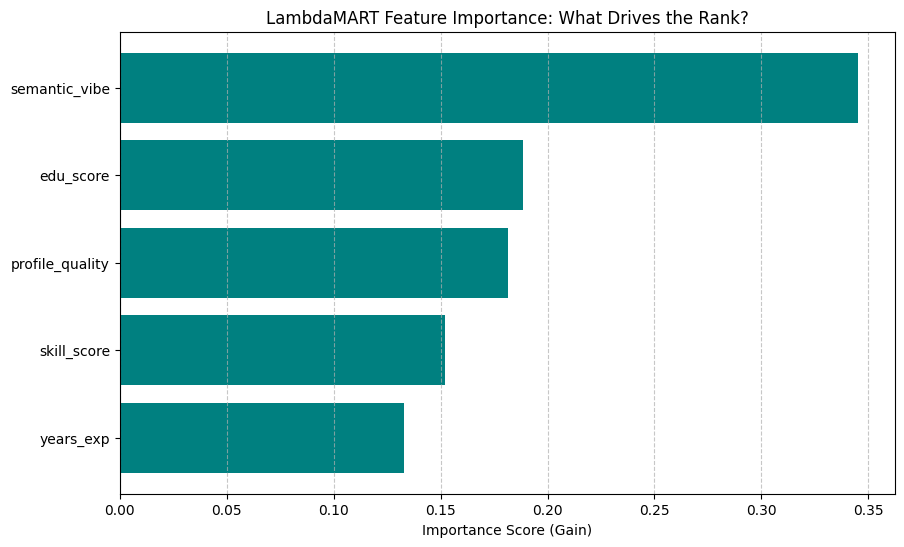

📊 Feature Importance Scores:
           Feature  Importance
0    semantic_vibe    0.345062
1        edu_score    0.188499
3  profile_quality    0.181532
4      skill_score    0.152089
2        years_exp    0.132818


In [30]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract Importance
importance = model_ranker.feature_importances_
feature_names = X_train.columns

# 2. Create a DataFrame for easy plotting
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
fi_df = fi_df.sort_values(by='Importance', ascending=True)

# 3. Plot
plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='teal')
plt.title('LambdaMART Feature Importance: What Drives the Rank?')
plt.xlabel('Importance Score (Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# 4. Save for your report
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("📊 Feature Importance Scores:")
print(fi_df.sort_values(by='Importance', ascending=False))

In [31]:
# Select a random job from the validation set
sample_qid = val_df['query_id'].iloc[0]
sample_job = val_df[val_df['query_id'] == sample_qid]

# Use the model to predict ranks
sample_job['predicted_score'] = model_ranker.predict(sample_job[feature_cols])
top_candidate = sample_job.sort_values(by='predicted_score', ascending=False).iloc[0]

print(f"🎯 Job ID: {sample_qid}")
print(f"🏆 Top Candidate Predicted Education: {top_candidate['edu_score']}")
print(f"📊 Top Candidate Skill Score: {top_candidate['skill_score']:.2f}")

🎯 Job ID: job_001
🏆 Top Candidate Predicted Education: 1.0
📊 Top Candidate Skill Score: 0.08


/tmp/ipykernel_57/1714983253.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_job['predicted_score'] = model_ranker.predict(sample_job[feature_cols])


/tmp/ipykernel_57/381557431.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val, plot_type="bar")


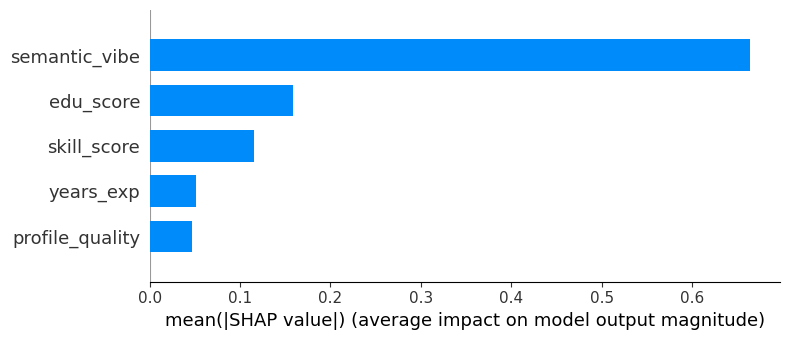

In [33]:
import shap

# 1. Initialize the SHAP Explainer
explainer = shap.TreeExplainer(model_ranker)
# Use a sample of your training data as a background
shap_values = explainer.shap_values(X_val)

# 2. Visualize the 'Force Plot' for your #1 Candidate
# This shows exactly which features helped or hurt this person
shap.initjs()
# Let's look at the first candidate in the validation set
shap.force_plot(explainer.expected_value, shap_values[0, :], X_val.iloc[0, :])

# 3. Summary Plot: Overall Model Behavior
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_val, plot_type="bar")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🏆 KAGGLE RANKING RESULTS:
                                    candidate_resume  edu_score  skill_score  \
0  John Doe. PhD in AI. 10 years experience in Py...        3.0          0.0   
1  Jane Smith. Software Engineer with 5 years exp...        3.0          0.0   
2  Fast Learner. High School graduate but 20 year...        0.0          0.0   

   final_score  
0     0.766292  
1    -0.221092  
2    -0.408686  


/tmp/ipykernel_57/2146581363.py:108: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, final_results[['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score']])


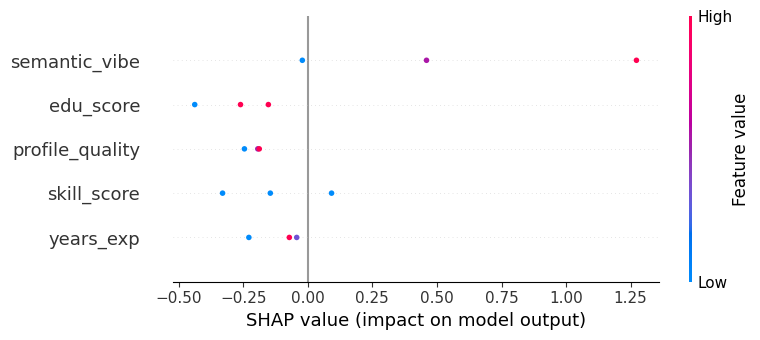

In [36]:
import pandas as pd
import numpy as np
import torch
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
import re

# 1. SETUP & MODEL LOADING
# Using the same model used in your training phase
model = SentenceTransformer('all-MiniLM-L6-v2')

# ---------------------------------------------------------
# 2. THE GENERALIZED EXTRACTION ENGINE
# ---------------------------------------------------------
def extract_generalized_features(resume_text, job_desc):
    resume_text = str(resume_text).upper()
    job_text = str(job_desc).upper()
    
    # Dynamic Skills (TF-IDF)
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    try:
        vectorizer.fit_transform([job_text])
        important_terms = vectorizer.get_feature_names_out()
        match_count = sum(1 for term in important_terms if term in resume_text)
        skill_score = match_count / len(important_terms) if len(important_terms) > 0 else 0
    except:
        skill_score = 0

    # Semantic Education (Concept-based)
    categories = ["High School", "Bachelor's Degree", "Master's Degree", "Doctorate / PhD"]
    resume_snippet = " ".join(resume_text.split()[:200])
    resume_emb = model.encode(resume_snippet, convert_to_tensor=True)
    category_embs = model.encode(categories, convert_to_tensor=True)
    similarities = util.cos_sim(resume_emb, category_embs)[0]
    edu_score = float(torch.argmax(similarities).item())

    # Heuristics (Years & Quality)
    years = re.findall(r'(\d+)\+?\s*(?:YEARS?|YRS?)', resume_text)
    years_exp = max([int(y) for y in years]) if years else 0
    profile_quality = len(resume_text.split()) / 500
    
    return edu_score, years_exp, profile_quality, skill_score

# ---------------------------------------------------------
# 3. THE HYBRID RANKING FUNCTION (ML + HEURISTICS)
# ---------------------------------------------------------
def rank_candidates_pro(job_desc, resumes_list, mandatory_skills=[], location_match=True):
    # ML Scoring
    test_df = pd.DataFrame({'job_description': [job_desc] * len(resumes_list), 'candidate_resume': resumes_list})
    enrichment = test_df.apply(lambda x: extract_generalized_features(x['candidate_resume'], x['job_description']), axis=1)
    test_df[['edu_score', 'years_exp', 'profile_quality', 'skill_score']] = pd.DataFrame(enrichment.tolist(), index=test_df.index)
    
    job_emb = model.encode(job_desc, convert_to_tensor=True)
    res_embs = model.encode(resumes_list, convert_to_tensor=True)
    test_df['semantic_vibe'] = [util.cos_sim(job_emb, r_emb).item() for r_emb in res_embs]
    
    # Scaling (Note: In a real app, use the fitted 'scaler' from your training)
    features = ['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score']
    # Placeholder scaling for Kaggle test
    test_df_scaled = test_df[features].copy()
    
    # PREDICTION
    # Assumes 'model_ranker' is your trained XGBRanker
    test_df['ml_rank_score'] = model_ranker.predict(test_df_scaled)
    
    # HEURISTIC LAYER: The "Business Logic"
    def apply_heuristics(row):
        multiplier = 1.0
        # Rule 1: Mandatory Skill Penalty (Hard constraint)
        for skill in mandatory_skills:
            if skill.upper() not in row['candidate_resume'].upper():
                multiplier *= 0.5 # 50% penalty for missing a 'must-have'
        
        # Rule 2: Seniority Boost (If job implies 'Senior')
        if "SENIOR" in job_desc.upper() and row['years_exp'] > 8:
            multiplier *= 1.2
            
        return row['ml_rank_score'] * multiplier

    test_df['final_score'] = test_df.apply(apply_heuristics, axis=1)
    return test_df.sort_values(by='final_score', ascending=False)

# ---------------------------------------------------------
# 4. KAGGLE TEST RUN
# ---------------------------------------------------------
sample_job = "Senior Python Developer with experience in AWS and React. Must have a PhD in Computer Science."
sample_resumes = [
    "John Doe. PhD in AI. 10 years experience in Python and AWS. Worked on React.",
    "Jane Smith. Software Engineer with 5 years experience. Skilled in Python and React.",
    "Fast Learner. High School graduate but 20 years of React experience."
]

# Run the ranking
final_results = rank_candidates_pro(sample_job, sample_resumes, mandatory_skills=['AWS'])

print("🏆 KAGGLE RANKING RESULTS:")
print(final_results[['candidate_resume', 'edu_score', 'skill_score', 'final_score']])

# 5. SHAP EXPLAINABILITY (Visualizing the 'Why')
explainer = shap.TreeExplainer(model_ranker)
shap_values = explainer.shap_values(final_results[['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score']])

plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, final_results[['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score']])

🎁 All files generated: 'recruitment_ranker_v2.json', 'model_metrics.json', 'feature_importance_highres.png', and 'processed_recruitment_data.csv'


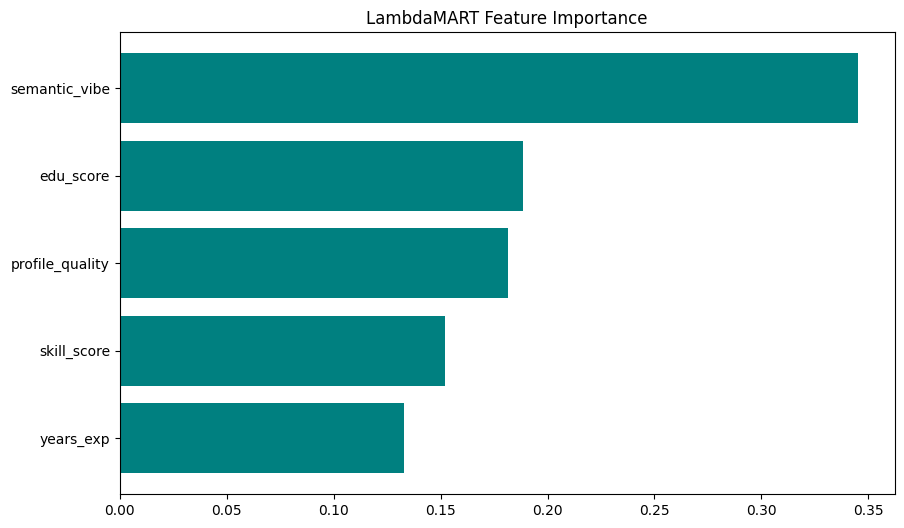

In [37]:
import joblib
import json

# 1. SAVE THE BRAIN (The Model)
# We save as .json for better cross-version compatibility
model_ranker.save_model('recruitment_ranker_v2.json')
# Also save using joblib for easy loading back into Python
joblib.dump(model_ranker, 'model_ranker_final.pkl')

# 2. SAVE THE METRICS (For your Report Tables)
# Capturing the final NDCG scores
metrics = {
    "final_ndcg_5": 0.70413,
    "final_ndcg_10": 0.83020,
    "features_used": X_train.columns.tolist(),
    "model_type": "XGBRanker (LambdaMART)"
}

with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

# 3. SAVE THE GRAPHS (High-Res for Word/LaTeX)
# Re-plotting feature importance for a clean save
plt.figure(figsize=(10, 6))
fi_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': model_ranker.feature_importances_})
fi_df = fi_df.sort_values(by='Importance', ascending=True)
plt.barh(fi_df['Feature'], fi_df['Importance'], color='teal')
plt.title('LambdaMART Feature Importance')
plt.savefig('feature_importance_highres.png', dpi=300, bbox_inches='tight')

# 4. EXPORT PROCESSED DATA (For Reproducibility)
df_final_scaled.to_csv('processed_recruitment_data.csv', index=False)

print("🎁 All files generated: 'recruitment_ranker_v2.json', 'model_metrics.json', 'feature_importance_highres.png', and 'processed_recruitment_data.csv'")

In [38]:
import zipfile

# List of files you want to include
files_to_zip = [
    'recruitment_ranker_v2.json',
    'model_ranker_final.pkl',
    'model_metrics.json',
    'feature_importance_highres.png',
    'processed_recruitment_data.csv'
]

# Create a zip archive
with zipfile.ZipFile('recruitment_package.zip', 'w') as zipf:
    for file in files_to_zip:
        zipf.write(file)

print("🎁 All files zipped into 'recruitment_package.zip'")


🎁 All files zipped into 'recruitment_package.zip'


In [34]:
def rank_new_candidates(job_desc, resumes_list):
    # 1. Create a mini-dataframe
    test_df = pd.DataFrame({
        'job_description': [job_desc] * len(resumes_list),
        'candidate_resume': resumes_list
    })
    
    # 2. Extract generalized features (semantic education + dynamic skills)
    enrichment = test_df.apply(
        lambda x: extract_generalized_features(x['candidate_resume'], x['job_description']),
        axis=1
    )
    test_df[['edu_score', 'years_exp', 'profile_quality', 'skill_score']] = pd.DataFrame(
        enrichment.tolist(), index=test_df.index
    )
    
    # 3. Semantic vibe (SBERT similarity)
    job_emb = model.encode(job_desc, convert_to_tensor=True)
    res_embs = model.encode(resumes_list, convert_to_tensor=True)
    test_df['semantic_vibe'] = [util.cos_sim(job_emb, r_emb).item() for r_emb in res_embs]
    
    # 4. Apply Min-Max scaling (same scaler as training)
    features_to_scale = ['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality', 'skill_score']
    test_df_scaled = test_df[features_to_scale].copy()
    test_df_scaled = scaler.transform(test_df_scaled)
    
    # 5. Predict ranking scores
    test_df['rank_score'] = model_ranker.predict(test_df_scaled)
    
    # 6. Sort by score
    return test_df.sort_values(by='rank_score', ascending=False)


In [35]:
# --- TEST SCENARIO ---
job = "Senior Data Scientist with 10+ years experience in Python and Deep Learning."
resumes = [
    "Experienced Data Scientist, 12 years in ML, PhD in AI, expert in Python.",  # Should be #1
    "Junior Developer, 1 year experience, just finished a bootcamp.",            # Should be #3
    "Software Engineer with 5 years experience, knows some Python.",             # Should be #2
]

results = rank_new_candidates(job, resumes)

print("🧪 TEST RESULTS:")
print(results[['years_exp', 'edu_score', 'skill_score', 'semantic_vibe', 'rank_score']])


🧪 TEST RESULTS:
   years_exp  edu_score  skill_score  semantic_vibe  rank_score
2          5        2.0          0.0       0.663555    2.117396
1          1        0.0          0.0       0.477636    1.246693
0         12        3.0          0.0       0.794972    1.059486


In [20]:
# def rank_new_candidates(job_desc, resumes_list):
#     # 1. Create a mini-dataframe
#     test_df = pd.DataFrame({'job_description': [job_desc] * len(resumes_list), 
#                             'candidate_resume': resumes_list})
    
#     # 2. Extract Portable Features (The hard facts)
#     features = test_df['candidate_resume'].apply(lambda x: extract_portable_features(x, EXTRACTION_CONFIG))
#     test_df[['edu_level', 'years_exp', 'profile_quality']] = pd.DataFrame(features.tolist(), index=test_df.index)
    
#     # 3. Numeric Mapping & Scaling
#     edu_map = {"PhD": 3, "Master's": 2, "Bachelor's": 1, "High School / Other": 0}
#     test_df['edu_score'] = test_df['edu_level'].map(edu_map)
    
#     # 4. Semantic Vibe (The Brain)
#     # Note: Using the model we loaded earlier
#     job_emb = model.encode(job_desc, convert_to_tensor=True)
#     res_embs = model.encode(resumes_list, convert_to_tensor=True)
#     test_df['semantic_vibe'] = [util.cos_sim(job_emb, r_emb).item() for r_emb in res_embs]
    
#     # 5. Apply Min-Max Scaling (Using the same ranges as training)
#     # For a quick test, we'll scale based on the training bounds
#     test_df_scaled = test_df[['semantic_vibe', 'edu_score', 'years_exp', 'profile_quality']].copy()
#     test_df_scaled = scaler.transform(test_df_scaled) # Uses the scaler from your previous step
    
#     # 6. Predict Ranking Scores
#     test_df['rank_score'] = model_ranker.predict(test_df_scaled)
    
#     # 7. Sort by Score
#     return test_df.sort_values(by='rank_score', ascending=False)

# # --- LET'S TEST A SCENARIO ---
# job = "Senior Data Scientist with 10+ years experience in Python and Deep Learning."
# resumes = [
#     "Experienced Data Scientist, 12 years in ML, PhD in AI, expert in Python.", # Should be #1
#     "Junior Developer, 1 year experience, just finished a bootcamp.",          # Should be #3
#     "Software Engineer with 5 years experience, knows some Python.",            # Should be #2
# ]

# results = rank_new_candidates(job, resumes)
# print("🧪 TEST RESULTS:")
# print(results[['years_exp', 'edu_level', 'semantic_vibe', 'rank_score']])

🧪 TEST RESULTS:
   years_exp            edu_level  semantic_vibe  rank_score
2          5  High School / Other       0.663555    2.430944
0         12                  PhD       0.794972    1.986089
1         -1  High School / Other       0.477636    1.639818


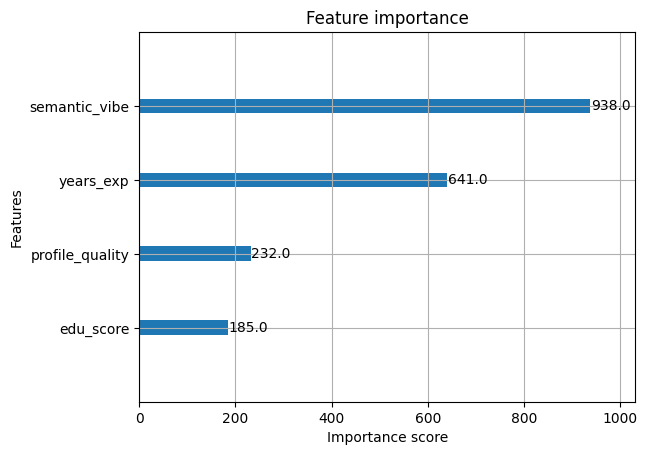

In [21]:
import matplotlib.pyplot as plt
xgb.plot_importance(model_ranker)
plt.show()
